In [2]:
%pip install seaborn

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Прочитайте данные (переменную назовите 'df')
df = pd.read_csv('data.csv')

# Вывести несколько первых строк таблицы данных
print(df.head())

         Дата  Склад Контрагент Номенклатура  Количество
0  2018-01-04      1  address_0    product_0           4
1  2018-01-04      1  address_0    product_1           4
2  2018-01-04      1  address_0    product_2           5
3  2018-01-04      1  address_0    product_3          10
4  2018-01-04      1  address_0    product_4           2


In [7]:
df.shape

(301355, 5)

### Проверяем формат столбцов

In [11]:
df.dtypes


Дата              str
Склад           int64
Контрагент        str
Номенклатура      str
Количество      int64
dtype: object

In [12]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 301355 entries, 0 to 301354
Data columns (total 5 columns):
 #   Column        Non-Null Count   Dtype
---  ------        --------------   -----
 0   Дата          301355 non-null  str  
 1   Склад         301355 non-null  int64
 2   Контрагент    301355 non-null  str  
 3   Номенклатура  301355 non-null  str  
 4   Количество    301355 non-null  int64
dtypes: int64(2), str(3)
memory usage: 8.0 MB


### Сразу переведем столбец "Дата" в правильный формат

In [15]:
df['Дата'] = pd.to_datetime(df['Дата'], format='%Y-%m-%d')

print('Пропуски:')
print(df.isna().sum())

Пропуски:
Дата            0
Склад           0
Контрагент      0
Номенклатура    0
Количество      0
dtype: int64


### Сгруппируйте данные по дате, посчитайте количество продаж

In [36]:
grouped_df = (df.groupby('Дата')['Количество']
      .sum(min_count=1)
      .sort_index()
)

grouped_df

Дата
2018-01-04    3734
2018-01-05    3643
2018-01-06    3193
2018-01-07    3298
2018-01-09    4055
              ... 
2018-08-26    5302
2018-08-28    5983
2018-08-29    4969
2018-08-30    4648
2018-08-31    4570
Name: Количество, Length: 205, dtype: int64

### Вывести несколько первых строк сгруппированных данных

In [37]:
print(grouped_df.head())

Дата
2018-01-04    3734
2018-01-05    3643
2018-01-06    3193
2018-01-07    3298
2018-01-09    4055
Name: Количество, dtype: int64


### Нарисуйте график продаж у `grouped_df`

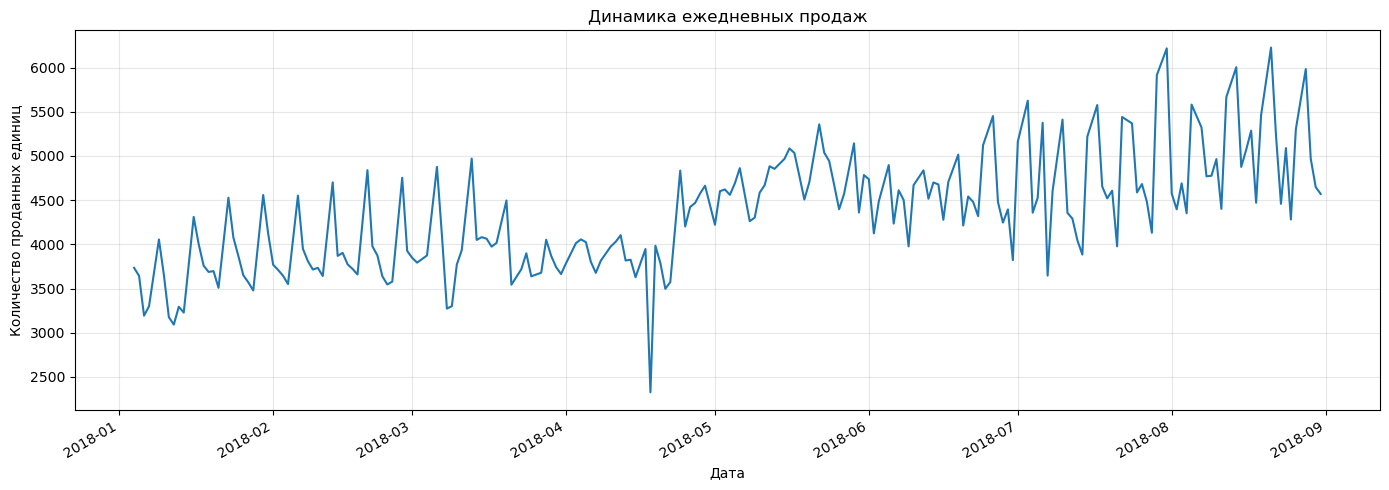

In [38]:
grouped_df.plot(
    figsize=(14, 5),
    legend=False,
    title='Динамика ежедневных продаж'
)

plt.xlabel('Дата')
plt.ylabel('Количество проданных единиц')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Опишите что вы видите на графике. Ваша задача - максимально описать график

На графике виден общий рост продаж. В апреле заметен резкий провал примерно до 2,3 тыс., а максимальные пики в конце июля и августе достигают 6,2 тыс. единиц. Общий уровень продаж повышается, но рост неравномерный.

### Найдите строку, у которой максимальный выброс по количеству продаж (нужно найти выброс у `df`)

In [39]:
df.loc[[df['Количество'].idxmax()]]

,Дата,Склад,Контрагент,Номенклатура,Количество
218822,2018-06-28,1,address_208,product_0,200


### Найдите топовый товар по продажам по средам за июнь, июль, август у 3 склада

In [40]:
top_product = (
    df[
        (df['Склад'] == 3)
        & (df['Дата'].dt.year == 2018)
        & (df['Дата'].dt.month.isin([6, 7, 8]))
        & (df['Дата'].dt.dayofweek == 2)
    ]
    .groupby('Номенклатура')['Количество']
    .sum()
    .nlargest(1)
)

top_product

Номенклатура
product_1    2267
Name: Количество, dtype: int64

### Скачайте данные по погоде с https://rp5.ru/Архив_погоды_в_Астане (скачайте исходные данные, и далее преобразуйте так, чтобы мы имели Дату и Среднюю температуру за день), объедините таблицу температуры с `grouped_df`, и нарисуйте график `y=['Количество продаж', 'T']`, где Т это температура. А также отдельно график температуры.

In [45]:
grouped_df = (df.groupby('Дата')['Количество']
      .sum(min_count=1)
      .sort_index()
)

grouped_df

Дата
2018-01-04    3734
2018-01-05    3643
2018-01-06    3193
2018-01-07    3298
2018-01-09    4055
              ... 
2018-08-26    5302
2018-08-28    5983
2018-08-29    4969
2018-08-30    4648
2018-08-31    4570
Name: Количество, Length: 205, dtype: int64

temperature: Date
2018-01-04   -14.0750
2018-01-05   -16.8625
2018-01-06   -13.3000
2018-01-07   -12.7500
2018-01-08   -15.4125
               ...   
2018-08-27    12.5250
2018-08-28    14.1125
2018-08-29    13.8250
2018-08-30    14.1750
2018-08-31    11.0250
Name: T, Length: 240, dtype: float64


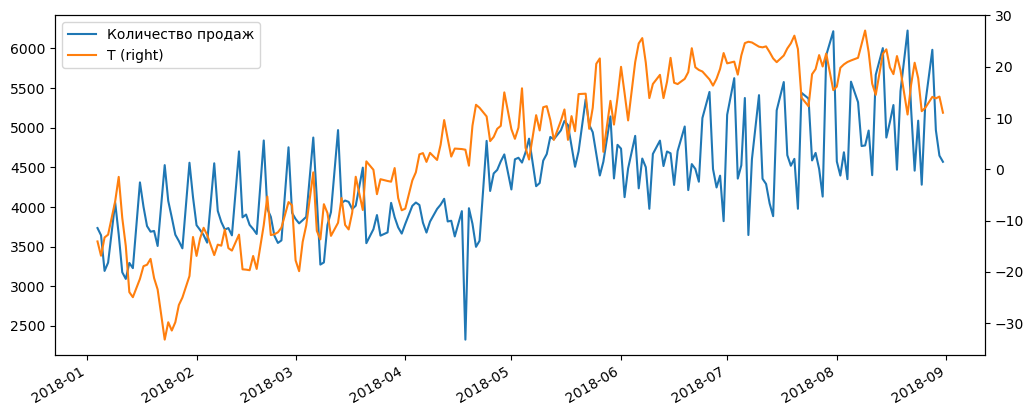

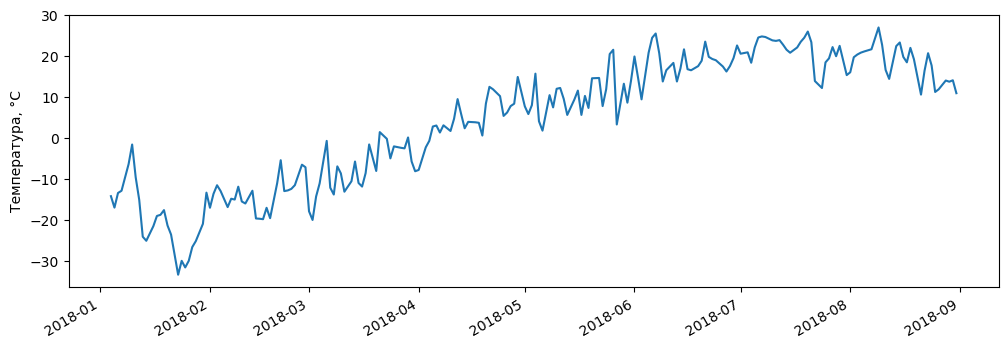

In [48]:
weather = pd.read_csv('Weather_KZ.csv', sep=';')
weather['Date'] = pd.to_datetime(weather['Date'])

# Средняя температура за день
temperature = weather.groupby('Date')['AVG_weather'].mean().rename('T')
print(f'temperature: {temperature}')

# Объединяем по дате
result = pd.concat(
    [grouped_df.rename('Количество продаж'), temperature.rename('T')],
    axis=1,
    join='inner'
).sort_index()

# Продажи и температура
result.plot(
    y=['Количество продаж', 'T'],
    secondary_y='T',
    figsize=(12, 5)
)
plt.show()

# Только температура
result['T'].plot(figsize=(12, 4), ylabel='Температура, °C')
plt.show()